#PROJECT-**DIABETES PREDICTION USING AI**

#IMPORT LIBRARIES & LOAD DATA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd

# Load Dataset
data = pd.read_csv("diabetes_prediction_dataset.csv")

print("Dataset Loaded Successfully")
data.head()

Dataset Loaded Successfully


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


#ANALYSE THE DATA

In [3]:
print("Shape:", data.shape)
data.info()


Shape: (100000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
data.describe()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
data.head(2000)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
1995,Female,53.0,1,0,never,26.39,5.8,140,0
1996,Female,43.0,0,0,No Info,27.32,5.7,159,0
1997,Female,80.0,0,0,never,27.32,6.6,100,0
1998,Male,71.0,0,0,No Info,27.32,6.0,155,0


In [6]:
print(data.columns)


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


#MISSING VALUE ANALYSIS & DATA IMPUTATION

In [7]:
data.isnull().sum()


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


#Separate Numeric & Categorical Columns

In [8]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numeric Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numeric Columns: Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='object')
Categorical Columns: Index(['gender', 'smoking_history'], dtype='object')


#Fill Missing Values






In [9]:
#numeric
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())


In [10]:
#categorical
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


In [11]:
data.isnull().sum()


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


#EDA & DATA VISUALIZATION

Diabetes Distribution

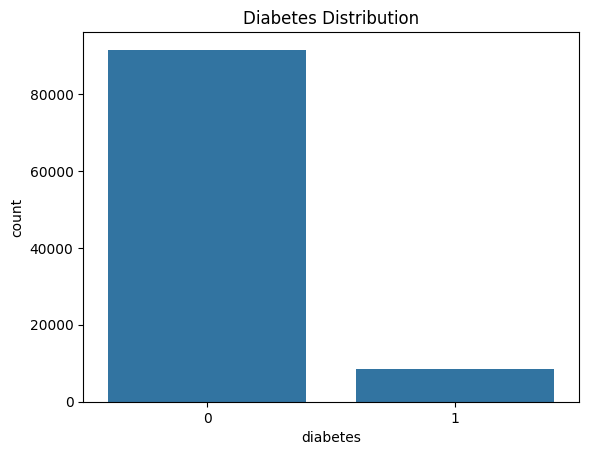

In [12]:
sns.countplot(x="diabetes", data=data)
plt.title("Diabetes Distribution")
plt.show()


Correlation Heatmap

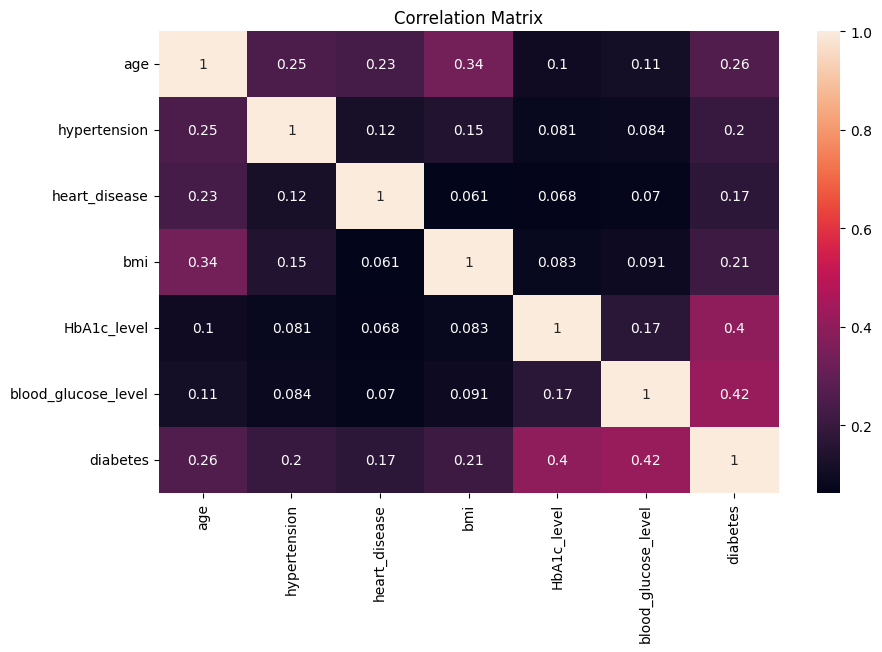

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()


AGE DISTRIBUTION

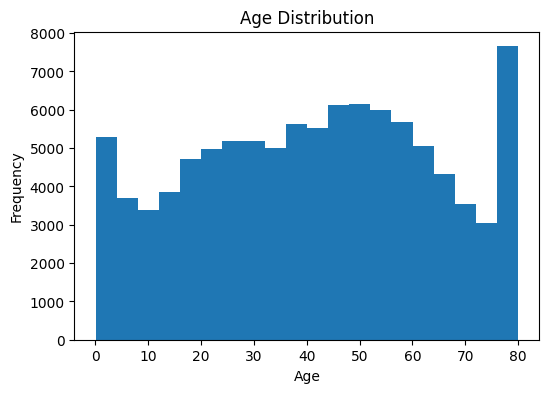

In [14]:
plt.figure(figsize=(6,4))

plt.hist(data["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


HbA1c DISTRIBUTION

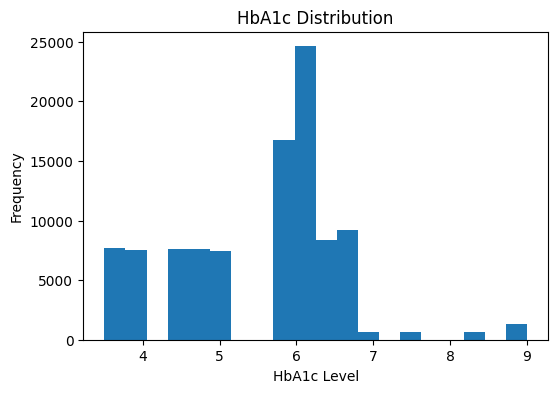

In [15]:
plt.figure(figsize=(6,4))

plt.hist(data["HbA1c_level"], bins=20)

plt.title("HbA1c Distribution")
plt.xlabel("HbA1c Level")
plt.ylabel("Frequency")

plt.show()


Age vs Glucose

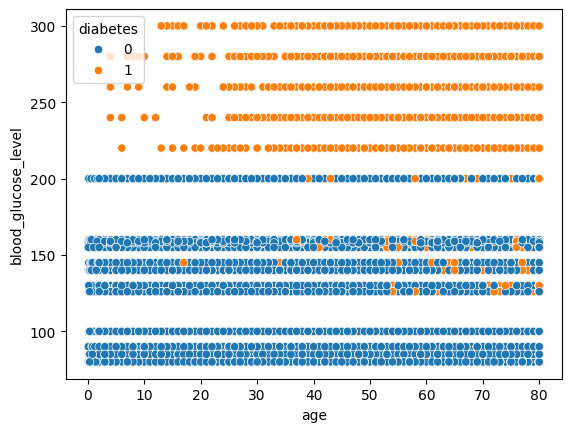

In [16]:
sns.scatterplot(
    x="age",
    y="blood_glucose_level",
    hue="diabetes",
    data=data
)
plt.show()


DATA ENCODING (STRING → NUMBER)

In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in cat_cols:
    data[col] = encoder.fit_transform(data[col])


check data type

In [18]:
data.dtypes


,0
gender,int64
age,float64
hypertension,int64
heart_disease,int64
smoking_history,int64
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


FEATURE & TARGET SEPARATION

In [19]:
X = data.drop("diabetes", axis=1)
y = data["diabetes"]


#PREPROCESSING, SCALING, SPLIT

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)



#ML MODELS

Logistic Regression (Regression Type)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Accuracy:", log_acc*100)


Logistic Accuracy: 95.87


#KNN (Conventional Classification)

In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc*100)


KNN Accuracy: 96.1


#Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc*100)


Random Forest Accuracy: 97.03500000000001


#Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc*100)


Decision Tree Accuracy: 95.16


#CLASSIFICATION USING NEURAL NETWORK

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = nn_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
nn_loss, nn_acc = nn_model.evaluate(X_test, y_test, verbose=1)

print("Neural Network Accuracy:", nn_acc*100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8583 - loss: 0.3026 - val_accuracy: 0.9576 - val_loss: 0.1161
Epoch 2/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9576 - loss: 0.1220 - val_accuracy: 0.9619 - val_loss: 0.1080
Epoch 3/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9637 - loss: 0.1061 - val_accuracy: 0.9651 - val_loss: 0.0999
Epoch 4/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9655 - loss: 0.1015 - val_accuracy: 0.9685 - val_loss: 0.0945
Epoch 5/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9682 - loss: 0.0950 - val_accuracy: 0.9688 - val_loss: 0.0928
Epoch 6/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9689 - loss: 0.0923 - val_accuracy: 0.9697 - val_loss: 0.0895
Epoch 7/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9699 - loss: 0.0881 - val_accuracy: 0.9699 - val_loss: 0.0880
Epoch 8/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9711 - loss: 0.0852 - 

graph

In [26]:
from sklearn.metrics import accuracy_score
import json


# -------- Evaluate Models --------

log_pred = log_model.predict(X_test)
knn_pred = knn.predict(X_test)
rf_pred = rf.predict(X_test)
nn_pred = nn_model.predict(X_test)
nn_pred = (nn_pred > 0.5).astype(int)


log_acc = accuracy_score(y_test, log_pred)
knn_acc = accuracy_score(y_test, knn_pred)
rf_acc = accuracy_score(y_test, rf_pred)
nn_acc = accuracy_score(y_test, nn_pred)


# -------- Save Scores --------

model_scores = {
    "Logistic": round(log_acc * 100, 2),
    "KNN": round(knn_acc * 100, 2),
    "Random Forest": round(rf_acc * 100, 2),
    "Neural Net": round(nn_acc * 100, 2)
}


with open("model_scores.json", "w") as f:
    json.dump(model_scores, f)


print("Saved model scores:")
print(model_scores)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Saved model scores:
{'Logistic': 95.87, 'KNN': 96.1, 'Random Forest': 97.04, 'Neural Net': 97.2}


In [27]:
import os
os.listdir()


['.config',
 'diabetes_prediction_dataset.csv',
 'model_scores.json',
 'sample_data']

#DIABETES PREDICTION

In [28]:
import numpy as np

print("\n========== DIABETES PREDICTION SYSTEM ==========\n")


# ----------- Gender -----------
gender_input = input("Enter Gender (M/F): ").strip().lower()

if gender_input == "m":
    gender = 1
elif gender_input == "f":
    gender = 0
else:
    print("Invalid input. Defaulting to Female.")
    gender = 0


# ----------- Age -----------
age = float(input("Enter Age: "))


# ----------- Hypertension -----------
bp_input = input("Do you have Hypertension? (Y/N): ").strip().lower()

if bp_input == "y":
    hypertension = 1
else:
    hypertension = 0


# ----------- Heart Disease -----------
heart_input = input("Do you have Heart Disease? (Y/N): ").strip().lower()

if heart_input == "y":
    heart = 1
else:
    heart = 0


# ----------- Smoking -----------
print("\nSmoking Options:")
print("0 = never")
print("1 = former")
print("2 = current")
print("3 = not current")
print("4 = no info")

smoke_input = input("Enter Smoking History (0-4): ").strip()

if smoke_input in ["0","1","2","3","4"]:
    smoke = int(smoke_input)
else:
    print("Invalid input. Defaulting to No Info.")
    smoke = 4


# ----------- BMI -----------
bmi = float(input("Enter BMI: "))


# ----------- HbA1c -----------
hba1c = float(input("Enter HbA1c Level: "))


# ----------- Glucose -----------
glucose = float(input("Enter Blood Glucose Level: "))


# ----------- Create Input Array -----------
new_patient = np.array([[
    gender,
    age,
    hypertension,
    heart,
    smoke,
    bmi,
    hba1c,
    glucose
]], dtype=float)


# ----------- Scale -----------
new_patient_scaled = scaler.transform(new_patient)


# ----------- Predict -----------
result = log_model.predict(new_patient_scaled)
prob = log_model.predict_proba(new_patient_scaled)


# ----------- Output -----------
print("\n========== RESULT ==========")

if result[0] == 1:
    print("🩺 Prediction: PERSON IS DIABETIC")
else:
    print("✅ Prediction: PERSON IS NOT DIABETIC")

print("Confidence Level:", round(prob[0][1]*100, 2), "%")

print("============================")



========== DIABETES PREDICTION SYSTEM ==========

Enter Gender (M/F): f
Enter Age: 21
Do you have Hypertension? (Y/N): n
Do you have Heart Disease? (Y/N): n

Smoking Options:
0 = never
1 = former
2 = current
3 = not current
4 = no info
Enter Smoking History (0-4): 3
Enter BMI: 25
Enter HbA1c Level: 5
Enter Blood Glucose Level: 123

========== RESULT ==========
✅ Prediction: PERSON IS NOT DIABETIC
Confidence Level: 0.02 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#Save and Download model

In [29]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Models saved successfully")


Models saved successfully


In [30]:
import joblib

log_model = joblib.load("logistic_model.pkl")
rf = joblib.load("rf_model.pkl")
scaler = joblib.load("scaler.pkl")

print("Models loaded successfully")


Models loaded successfully


#Downloading the Trained Models

In [31]:
!pip install gradio joblib
import joblib
import numpy as np
import gradio as g

In [32]:
import joblib
import json # Import the json library

log_model = joblib.load("logistic_model.pkl")
rf = joblib.load("rf_model.pkl")
scaler = joblib.load("scaler.pkl")
score = json.load(open("model_scores.json", "r")) # Use json.load for JSON files
print("Models loaded successfully")

Models loaded successfully


In [33]:
import json

def model_insights():

    with open("model_scores.json", "r") as f:
        scores = json.load(f)

    models = list(scores.keys())
    accuracy = list(scores.values())

    fig, ax = plt.subplots(figsize=(7,4))

    ax.bar(models, accuracy, color="#b91c1c")

    ax.set_ylim(80, 100)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Model Performance Comparison")

    for i, v in enumerate(accuracy):
        ax.text(i, v+0.5, f"{v}%", ha="center")

    plt.tight_layout()

    return fig

In [34]:

import os

print(os.listdir())

['.config', 'rf_model.pkl', 'logistic_model.pkl', 'diabetes_prediction_dataset.csv', 'scaler.pkl', 'model_scores.json', 'sample_data']


In [35]:
def predict_diabetes(gender, age, hypertension, heart,
                     smoking, bmi, hba1c, glucose):

    gender = 1 if gender == "Male" else 0
    hypertension = 1 if hypertension == "Yes" else 0
    heart = 1 if heart == "Yes" else 0

    smoke_map = {
        "never": 0,
        "former": 1,
        "current": 2,
        "not current": 3,
        "no info": 4
    }

    smoking = smoke_map[smoking]

    data = np.array([[gender, age, hypertension,
                      heart, smoking, bmi,
                      hba1c, glucose]], dtype=float)

    data_scaled = scaler.transform(data)

    prob = log_model.predict_proba(data_scaled)[0][1]

    if prob >= 0.5:
        return f"🩺 DIABETIC\nProbability: {round(prob*100,2)}%"
    else:
        return f"✅ NOT DIABETIC\nProbability: {round(prob*100,2)}%"


#User Interface

In [36]:
import json
import joblib
import numpy as np
import gradio as gr
import matplotlib.pyplot as plt


# ---------------- Load Models ----------------
log_model = joblib.load("logistic_model.pkl")
scaler = joblib.load("scaler.pkl")


# ---------------- Prediction Function ----------------
def predict_diabetes(gender, age, hypertension, heart,
                     smoking, bmi, hba1c, glucose):

    gender = 1 if gender == "Male" else 0
    hypertension = 1 if hypertension == "Yes" else 0
    heart = 1 if heart == "Yes" else 0

    smoke_map = {
        "never": 0,
        "former": 1,
        "current": 2,
        "not current": 3,
        "no info": 4
    }

    smoking = smoke_map[smoking]

    data = np.array([[gender, age, hypertension,
                      heart, smoking, bmi,
                      hba1c, glucose]], dtype=float)

    data_scaled = scaler.transform(data)

    prob = log_model.predict_proba(data_scaled)[0][1]

    if prob >= 0.5:
        risk = "🔴 HIGH RISK"
        advice = "Please consult a doctor immediately."
    else:
        risk = "🟢 LOW RISK"
        advice = "Maintain a healthy lifestyle."


    result = f"""
## 🧾 Prediction Result

**Risk Level:** {risk}

**Confidence:** {round(prob*100,2)} %

**Advice:** {advice}
"""

    return result


# ---------------- AI Model Comparison ----------------

def model_insights():

    with open("model_scores.json", "r") as f:
        scores = json.load(f)

    models = list(scores.keys())
    accuracy = list(scores.values())

    fig, ax = plt.subplots(figsize=(7,4))

    ax.bar(models, accuracy, color="#b91c1c")

    ax.set_ylim(90, 100)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Model Performance Comparison")

    for i, v in enumerate(accuracy):
        ax.text(i, v+0.3, f"{v}%", ha="center")

    plt.tight_layout()

    return fig


# ---------------- Custom CSS ----------------
custom_css = """
html, body {
    width: 100% !important;
    height: 100% !important;
    margin: 0 !important;
    padding: 0 !important;
    background-color: #020617 !important;
}

.gradio-container,
.main,
.wrap,
.container,
.app,
.block {
    max-width: 100% !important;
    width: 100% !important;
    margin: 0 auto !important;
    padding: 10px !important;
    background-color: #020617 !important;
}

.header {
    background: linear-gradient(90deg, #7f1d1d, #b91c1c);
    padding: 25px;
    text-align: center;
}

.panel {
    background-color: #020617;
    border: 2px solid #b91c1c;
    border-radius: 12px;
    padding: 20px;
}

.normal-box {
    min-height: 260px !important;
}

.result-box {
    min-height: 360px !important;
}

.gr-button-primary {
    background-color: #b91c1c !important;
    border: none !important;
    width: 100% !important;
    font-size: 18px !important;
}

h1, h2, h3 {
    color: white !important;
    text-align: center;
}

table {
    color: white !important;
    width: 100% !important;
}
"""


# ---------------- UI Dashboard ----------------
with gr.Blocks(css=custom_css) as demo:


    # ---------- HEADER ----------
    gr.Markdown("""
    <div class="header">
        <h1>🏥 AI-Based Diabetes Prediction System</h1>
        <h3>Professional Healthcare Dashboard</h3>
    </div>
    """)


    # ================= TAB 1 : Prediction =================
    with gr.Tab("🧪 Prediction"):

        with gr.Row():


            # -------- INPUT PANEL --------
            with gr.Column(scale=3):

                with gr.Group(elem_classes="panel"):

                    gr.Markdown("## 📝 Patient Details")

                    gender = gr.Radio(["Male", "Female"], label="Gender")
                    age = gr.Number(label="Age", value=30)

                    hypertension = gr.Radio(["Yes", "No"], label="Hypertension")
                    heart = gr.Radio(["Yes", "No"], label="Heart Disease")

                    smoking = gr.Dropdown(
                        ["never", "former", "current", "not current", "no info"],
                        label="Smoking History"
                    )

                    bmi = gr.Number(label="BMI", value=25)
                    hba1c = gr.Number(label="HbA1c (%)", value=5.5)
                    glucose = gr.Number(label="Glucose (mg/dL)", value=120)

                    predict_btn = gr.Button("🔍 Predict Risk", variant="primary")


            # -------- RIGHT PANEL --------
            with gr.Column(scale=2):


                # Normal Ranges
                with gr.Group(elem_classes="panel normal-box"):

                    gr.Markdown("## 📊 Normal Ranges")

                    gr.Markdown("""
                    | Parameter | Normal | Diabetes |
                    |-----------|--------|----------|
                    | BMI | 18.5 – 24.9 | ≥ 30 |
                    | HbA1c | < 5.7 | ≥ 6.5 |
                    | Glucose | < 140 | ≥ 200 |
                    """)


                # Prediction Result
                with gr.Group(elem_classes="panel result-box"):

                    gr.Markdown("## 📋 Prediction Result")

                    output = gr.Markdown()



        predict_btn.click(
            fn=predict_diabetes,
            inputs=[
                gender, age, hypertension, heart,
                smoking, bmi, hba1c, glucose
            ],
            outputs=output
        )


    # ================= TAB 2 : About =================
    with gr.Tab("📘 About Diabetes"):

        gr.Markdown("""
        ## What is Diabetes?

        Diabetes is a chronic metabolic disorder that affects
        how the body controls blood sugar.

        Long-term high sugar damages organs.

        ### Types
        - Type 1
        - Type 2
        - Gestational

        ### Symptoms
        - Fatigue
        - Frequent urination
        - Blurred vision
        - Weight loss
        - Increased thirst

        ### Complications
        - Heart disease
        - Kidney failure
        - Stroke
        - Vision loss
        """)


    # ================= TAB 3 : Prevention =================
    with gr.Tab("🛡️ Prevention"):

        gr.Markdown("""
        ## Prevention & Care

        ✅ Exercise
        ✅ Healthy Diet
        ✅ Weight Control
        ✅ Avoid Smoking
        ✅ Regular Checkups
        """)

        gr.Markdown("""
        <div style="text-align:center;">

        <img src="https://cdn-icons-png.flaticon.com/512/2936/2936886.png" width="90"/>
        <img src="https://cdn-icons-png.flaticon.com/512/706/706195.png" width="90"/>
        <img src="https://cdn-icons-png.flaticon.com/512/2966/2966484.png" width="90"/>

        </div>
        """)


    # ================= TAB 4 : AI Insights =================
    with gr.Tab("🤖 AI Insights"):

        gr.Markdown("## 📊 Model Performance Comparison")

        insight_plot = gr.Plot()

        insight_btn = gr.Button("Generate Accuracy Chart")

        insight_btn.click(
            fn=model_insights,
            inputs=[],
            outputs=insight_plot
        )




demo.launch()


/tmp/ipython-input-3157495758.py:150: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://02ccfe082d7181cb6a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [37]:
!zip -r diabetes_project.zip .

  adding: .config/ (stored 0%)
  adding: .config/.last_update_check.json (deflated 25%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.02.06/ (stored 0%)
  adding: .config/logs/2026.02.06/14.31.35.535753.log (deflated 58%)
  adding: .config/logs/2026.02.06/14.31.45.734270.log (deflated 56%)
  adding: .config/logs/2026.02.06/14.30.32.592228.log (deflated 92%)
  adding: .config/logs/2026.02.06/14.31.44.938153.log (deflated 57%)
  adding: .config/logs/2026.02.06/14.31.19.332851.log (deflated 58%)
  adding: .config/logs/2026.02.06/14.31.28.771044.log (deflated 86%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/active_config (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/gce (stored 0%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_ca